# Проверка гипотез

## Задача 1

Данные Nursing Home Data <br>

Описание переменных<br>
BED = число коек в больнице <br>
MCDAYS = annual medical in-patient days (hundreds)<br>
TDAYS = annual total patient days (hundreds)<br>
PCREV = получено от пациентов за год ( в сотнях долларов)<br>
NSAL = годовой оклад медсестры (в сотнях долларов)<br>
FEXP = расходы больницы за год (сотни долларов) <br>
RURAL = код типа больницы: загородная (код 1) или городская (код 0) <br>

Цель: Сравнить расходы больницы за год (сотни долларов) для больниц расположенных за городом и в городе.

**Формулировка гипотез:** <br>
**H0:** распределения FEXP в группах одинаковы. <br>
**H1:** различаются.<br>

Уровень значимости: $\alpha = 0.05$ <br>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro

In [2]:
df = pd.read_csv("Nursing Home Data_data", sep='\s+')
df.head()

,BED,MCDAYS,TDAYS,PCREV,NSAL,FEXP,RURAL
0,244,128,385,23521,5230,5334,0
1,59,155,203,9160,2459,493,1
2,120,281,392,21900,6304,6115,0
3,120,291,419,22354,6590,6346,0
4,120,238,363,17421,5362,6225,0


In [3]:
df.shape

(52, 7)

In [4]:
df.isna().sum()

BED       0
MCDAYS    0
TDAYS     0
PCREV     0
NSAL      0
FEXP      0
RURAL     0
dtype: int64

In [5]:
df.dtypes

BED       int64
MCDAYS    int64
TDAYS     int64
PCREV     int64
NSAL      int64
FEXP      int64
RURAL     int64
dtype: object

In [6]:
df.describe().round(2)

,BED,MCDAYS,TDAYS,PCREV,NSAL,FEXP,RURAL
count,52.00,52.00,52.00,52.00,52.00,52.00,52.00
mean,93.27,183.87,280.17,14210.13,3812.83,2847.54,0.65
std,40.85,87.03,120.85,6973.76,1659.48,1949.03,0.48
min,25.00,48.00,83.00,2853.00,1288.00,137.00,0.00
25%,62.00,125.25,198.00,8857.00,2336.50,1229.25,0.00
50%,88.00,164.50,279.00,12384.00,3696.00,2377.50,1.00
75%,120.00,229.00,363.75,18777.25,4840.00,4443.75,1.00
max,244.00,514.00,776.00,36029.00,7489.00,6442.00,1.00


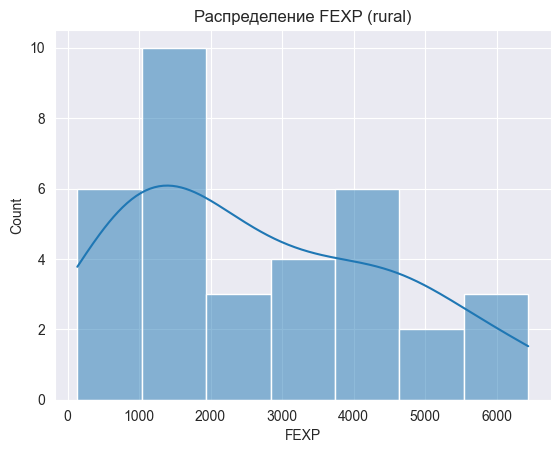

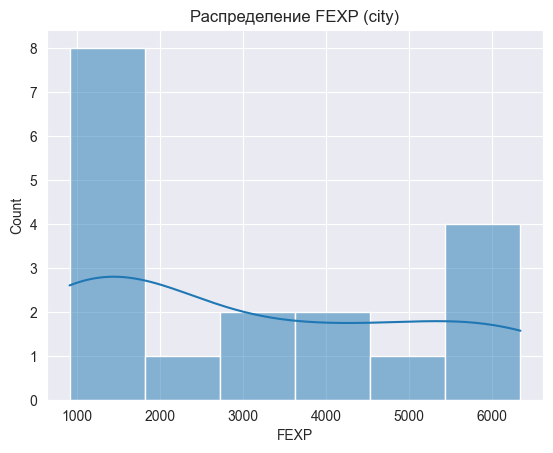

In [7]:
sns.histplot(df[df['RURAL'] == 1]['FEXP'], kde=True)
plt.title("Распределение FEXP (rural)")
plt.show()

sns.histplot(df[df['RURAL'] == 0]['FEXP'], kde=True)
plt.title("Распределение FEXP (city)")
plt.show()

Для переменной FEXP применим Shapiro–Wilk test для проверки нормальности

Гипотезы теста:<br>
H0: данные имеют нормальное распределение <br>
H1: распределение отличается от нормального<br>

In [8]:
city = df[df['RURAL'] == 0]['FEXP']
rural = df[df['RURAL'] == 1]['FEXP']

print(shapiro(city))
print(shapiro(rural))

ShapiroResult(statistic=np.float64(0.8286288074971696), pvalue=np.float64(0.0039692923780074675))
ShapiroResult(statistic=np.float64(0.9337157270495051), pvalue=np.float64(0.04017793201644691))


In [9]:
df["RURAL_lbl"] = df["RURAL"].map({0: "City", 1: "Rural"})

d = df[["FEXP", "RURAL_lbl"]]

d.groupby("RURAL_lbl")["FEXP"].agg(["count","mean","std","median",
                                   (lambda x: x.quantile(0.25)),
                                   (lambda x: x.quantile(0.75))]).rename(
    columns={"<lambda_0>":"q25","<lambda_1>":"q75"}
).round(2)

,count,mean,std,median,q25,q75
RURAL_lbl,,,,,,
City,18,3175.67,2137.25,2737.0,1242.00,5058.25
Rural,34,2673.82,1851.43,2377.5,1217.25,4305.50




Выбор критерия: Так как распределение переменной FEXP в обеих группах не является нормальным, применение параметрического t-теста, поэтому используем критерий Манна–Уитни для двух независимых выборок (двусторонний).

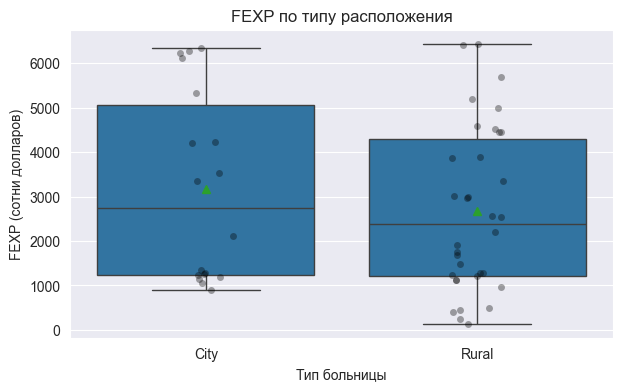

In [10]:
plt.figure(figsize=(7,4))
sns.boxplot(data=d, x="RURAL_lbl", y="FEXP", showmeans=True)
sns.stripplot(data=d, x="RURAL_lbl", y="FEXP", color="black", alpha=0.35)
plt.title("FEXP по типу расположения")
plt.xlabel("Тип больницы")
plt.ylabel("FEXP (сотни долларов)")
plt.show()

In [11]:
res = stats.mannwhitneyu(city, rural, alternative="two-sided")
res

MannwhitneyuResult(statistic=np.float64(339.0), pvalue=np.float64(0.5318951889778383))

In [12]:
print(f"U = {res.statistic:.3f}, p-value = {res.pvalue:.5f}")
alpha = 0.05
if res.pvalue < alpha:
    print("Отвергаем H0: различия в FEXP между городом и загородом статистически значимы.")
else:
    print("Не отвергаем H0: статистически значимых различий в FEXP не обнаружено.")

U = 339.000, p-value = 0.53190
Не отвергаем H0: статистически значимых различий в FEXP не обнаружено.


## Задача 2

Данные Unions and State Labor Law_data <br>

Variable Names: <br>
DENS: 	Percent of public sector employees in unions, 1982 <br>
COMP: 	State bargaining laws cover public employees (1) or not (0) <br>
RTW: 	State right-to-work law (1) or not (0) <br>
PVT: 	Percent of private sector employees in unions, 1982 <br>

Number of cases: 50 <br>

Цель: Сравнить процент муниципальных служащих, состоящих в профсоюзах в 1982 в разных штатах США. Сравниваются штаты, отличающиеся по тому, принят ли в этих штатах соответствующий закон (код 1) или не принят (код 0). Закон State right-to-work law

**Формулировка гипотез:** <br>
**H0:** распределения процента работников государственного сектора, состоящих в профсоюзах (DENS), одинаковы в штатах с законом Right-to-Work и без него.<br>
**H1:** распределения различаются.<br>

Уровень значимости: $\alpha = 0.05$ <br>

In [13]:
df_2 = pd.read_csv("Unions and State Labor Law_data", sep='\s+')
df_2.head()

,STATE,DENS,COMP,RTW,PVT
0,NY,56.9,1,0,31.2
1,MI,49.6,1,0,30.2
2,WA,32.4,1,0,33.1
3,HI,54.6,1,0,24.7
4,AK,30.7,1,0,30.1


In [14]:
df_2.shape

(50, 5)

In [15]:
df_2.isna().sum()

STATE    0
DENS     0
COMP     0
RTW      0
PVT      0
dtype: int64

In [16]:
df_2.dtypes

STATE     object
DENS     float64
COMP       int64
RTW        int64
PVT      float64
dtype: object

In [17]:
df_2.describe().round(2)

,DENS,COMP,RTW,PVT
count,50.00,50.00,50.00,50.00
mean,33.32,0.54,0.40,16.05
std,11.51,0.50,0.49,7.83
min,13.40,0.00,0.00,3.90
25%,25.18,0.00,0.00,9.95
50%,31.85,1.00,0.00,14.15
75%,40.65,1.00,1.00,22.88
max,61.10,1.00,1.00,33.10


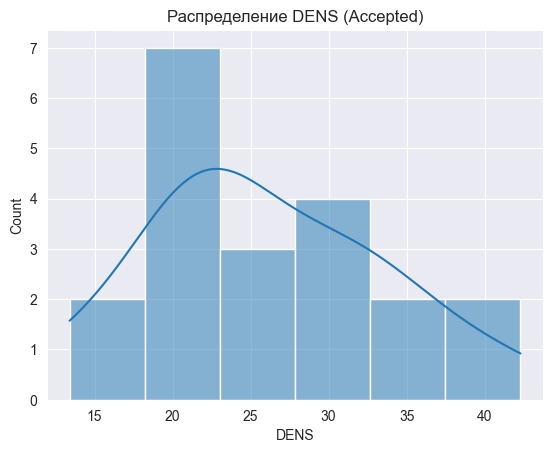

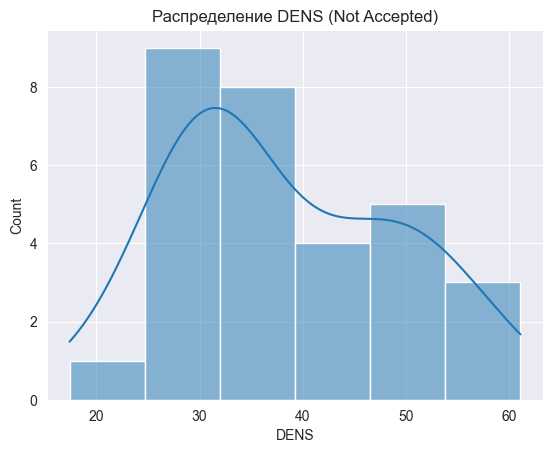

In [18]:
sns.histplot(df_2[df_2['RTW']==1]['DENS'], kde=True)
plt.title("Распределение DENS (Accepted)")
plt.show()

sns.histplot(df_2[df_2['RTW']==0]['DENS'], kde=True)
plt.title("Распределение DENS (Not Accepted)")
plt.show()

Для переменной DENS применим Shapiro–Wilk test для проверки нормальности

Гипотезы теста:<br>
H0: данные имеют нормальное распределение <br>
H1: распределение отличается от нормального<br>

In [19]:
rtw_accept = df_2[df_2['RTW']==1]['DENS']
rtw_not_accept = df_2[df_2['RTW']==0]['DENS']

print(shapiro(rtw_accept))
print(shapiro(rtw_not_accept))

ShapiroResult(statistic=np.float64(0.9649368935931816), pvalue=np.float64(0.6463982551328014))
ShapiroResult(statistic=np.float64(0.9520448987536858), pvalue=np.float64(0.19172901843820853))


В обеих группах p-value > 0.05 => нет оснований отвергать гипотезу о нормальности распределения.
Тогда выбираем критерий Welch t-test (equal_var=False), потому что дисперсии могут отличаться

In [20]:
df_2["RTW_lbl"] = df_2["RTW"].map({0: "Not Accepted", 1: "Accepted"})

d_2 = df_2[["DENS", "RTW_lbl"]]

df_2.groupby("RTW_lbl")["DENS"].agg(["count","mean","std","median",
                                   (lambda x: x.quantile(0.25)),
                                   (lambda x: x.quantile(0.75))]).rename(
    columns={"<lambda_0>":"q25","<lambda_1>":"q75"}
).round(2)

,count,mean,std,median,q25,q75
RTW_lbl,,,,,,
Accepted,20,26.01,7.66,23.55,21.25,31.65
Not Accepted,30,38.20,11.12,34.00,30.62,47.32


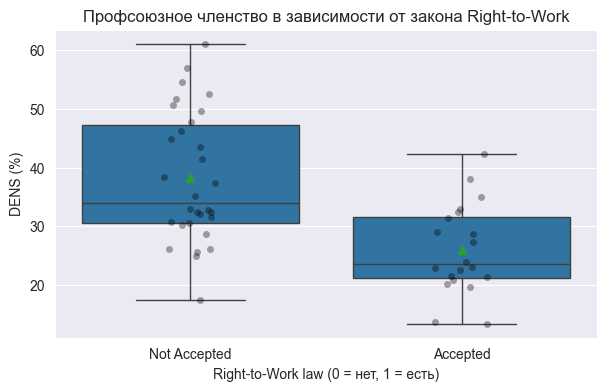

In [21]:
plt.figure(figsize=(7,4))
sns.boxplot(data=d_2, x="RTW_lbl", y="DENS", showmeans=True)
sns.stripplot(data=d_2, x="RTW_lbl", y="DENS", color="black", alpha=0.35)

plt.xlabel('Right-to-Work law (0 = нет, 1 = есть)')
plt.ylabel('DENS (%)')
plt.title('Профсоюзное членство в зависимости от закона Right-to-Work')

plt.show()

In [22]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(rtw_accept, rtw_not_accept, equal_var=False)

print(stat, p)

-4.588691016623043 3.2286849612861966e-05


In [23]:
print(f"U = {stat:.3f}, p-value = {p:.5f}")
alpha = 0.05
if p < alpha:
    print("Отвергаем H0: различия в DENS между штатаами с законом Right-to-Work и без него статистически значимы.")
else:
    print("Не отвергаем H0: статистически значимых различий в DENS не обнаружено.")

U = -4.589, p-value = 0.00003
Отвергаем H0: различия в DENS между штатаами с законом Right-to-Work и без него статистически значимы.
